# Real Local CV-RAG Inference on the A10 VM

This notebook captures a non-deterministic local inference run on `vm-cvrag-a10-poc`. The result is not the template fallback: BLIP captioned the query photo locally, CLIP embedded the text + image + caption for SQLite vector search, and Phi-4-mini ONNX generated the final answer from retrieved evidence.


## What ran locally

| Stage | Executed model/runtime | Result |
| --- | --- | --- |
| Photo understanding | `Salesforce/blip-image-captioning-base` | Caption: `a construction site photo of a concrete wall` |
| Vector retrieval | `openai/clip-vit-base-patch32` + SQLite brute-force cosine similarity | Inputs: text, image, caption |
| Answer drafting | `microsoft/Phi-4-mini-instruct-onnx` via ONNX Runtime GenAI | Provider: `follow_config`; model path: `/opt/models/Phi-4-mini-instruct-onnx/cpu_and_mobile/cpu-int4-rtn-block-32-acc-level-4` |
| A10 GPU finding | `gpu/gpu-int4-rtn-block-32` downloaded successfully | It did not fit in the 4 GB A10-4Q framebuffer, so the successful run used the official CPU/mobile int4 package for Phi-4-mini. |


Real local inference query and retrieval 
 
 Query photo BLIP caption: a construction site photo of a concrete wall 
 
 Top retrieved local evidence 
 
 #1 INC-001 Basement wall water ingress observed at construction joint Score: 0.8833 Severity: high 
 #2 INC-006 Hairline crack observed near lift core wall opening Score: 0.8166 Severity: medium 
 #3 INC-002 Concrete column honeycombing detected after form removal Score: 0.8098 Severity: high
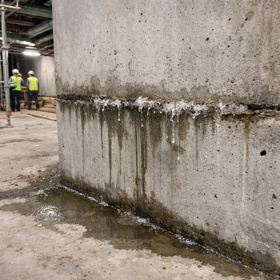
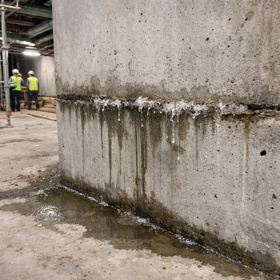
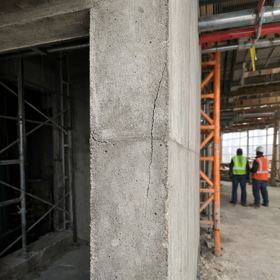
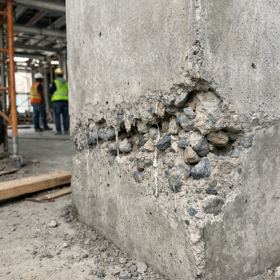

In [1]:
from IPython.display import HTML, display
# Executed output below embeds the query photo and retrieval thumbnails.
display(HTML(real_local_result_html))


## User question and Phi-4-mini response

**User question:** The photo shows active water seepage at a basement wall joint. What previous case is most relevant and what should we do next?

**Top retrieved case:** `INC-001` - Basement wall water ingress observed at construction joint (`score=0.8833`, severity `high`)

**Model response:**

> The photo you provided shows active water seepage at a basement wall joint. Based on the retrieved evidence, the most relevant incident ID for this situation is INC-001. Here are the next steps you should take:
> 1. Mark and photograph the full extent of the seepage and note the elevation and chainage references. This information will help in understanding the scale and location of the problem.
> 2. Inspect the joint detailing, the continuity of the waterproofing membrane, and check for any penetrations or ties and sealant repairs. This step is crucial to identify the root cause of the water ingress.
> 3. Check the adjacent drainage and sump operations to ensure they are functioning correctly. External water management conditions should also be reviewed to rule out any contributing factors from the surroundings.
> 4. Implement temporary water control measures to prevent further damage. This might include isolating any affected electrical or finish-sensitive areas.
> 5. Prepare a corrective action for a waterproofing specialist to review and retest after the repair work is completed.
> If the leakage increases, reaches active electrical equipment, or shows signs of wall movement, cracking, or soil washout, you should escalate the situation immediately to the appropriate level of structural or waterproofing expertise.
> Grounded in the evidence from incident ID INC-001, these actions are specifically tailored to address the high-severity water ingress issue you've observed at the basement wall joint.


## Timing from the VM run

| Step | Seconds |
| --- | --- |
| BLIP image caption | 1.853 |
| CLIP retrieval over SQLite | 1.524 |
| Phi-4-mini load + generation | 49.084 |
| Phi-4-mini decode loop only | 21.44 |
